# Force–orientation correlation

For each ABP particle we have, at every output frame:

- the **net pair-interaction force** $\mathbf{F}_i(t)$ (the `forces` dataset added to the trajectory writer — does NOT include active drive or anchor spring), and
- the **orientation unit vector** $\hat{\mathbf{n}}_i(t) = (\cos\theta_i(t),\, \sin\theta_i(t))$ along which the active force acts.

This notebook computes two quantities:

1. the **time-averaged dot product** $\langle \mathbf{F}_i \cdot \hat{\mathbf{n}}_i \rangle_t$ (per particle, and the population mean), and
2. the **cross-correlation function** $C(\tau) = \langle \mathbf{F}_i(t+\tau) \cdot \hat{\mathbf{n}}_i(t) \rangle_{i, t}$.

For a self-propelled particle pressing into an obstacle, $\mathbf{F}_i$ tends to oppose $\hat{\mathbf{n}}_i$, so the dot product should be negative on average.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt
from bdtrajectory import BDTrajectory

%matplotlib inline
plt.rcParams.update({'figure.dpi': 150})

## Load the trajectory

`BDTrajectory.forces(i)` returns the per-frame pair-interaction force array (shape `(N, 2)`); `BDTrajectory.orientations(i)` returns $\theta_i$. We stack them into `(T, N, 2)` and `(T, N)` arrays for vectorised analysis.

In [2]:
TRAJ_PATH = Path('..') / 'trajectory_highPe_highDe.h5'   # adjust if needed

traj = BDTrajectory(TRAJ_PATH)
print(traj)

if not traj.is_active:
    raise RuntimeError(
        'This trajectory is passive (f0 = 0); the force-orientation product '
        'is just F dotted with an arbitrary angle and carries no physical meaning.'
    )

if traj.forces(0) is None:
    raise RuntimeError(
        "Trajectory file has no 'forces' dataset. Re-run the simulation with "
        "the updated TrajectoryWriter that emits per-frame interaction forces."
    )

T = traj.num_frames
N = traj.N
times = traj.all_times()

# Stack per-frame data into (T, N, 2) for forces and (T, N) for theta.
forces = np.empty((T, N, 2), dtype=np.float64)
theta  = np.empty((T, N),    dtype=np.float64)
for k in range(T):
    forces[k] = traj.forces(k)
    theta [k] = traj.orientations(k)

# Orientation unit vectors n_i(t), shape (T, N, 2).
nhat = np.stack((np.cos(theta), np.sin(theta)), axis=-1)

# Per-frame, per-particle scalar  s_i(t) = F_i(t) . nhat_i(t),  shape (T, N).
s = np.einsum('tnk,tnk->tn', forces, nhat)

print(f'frames T = {T}, particles N = {N}, time span = [{times[0]:.4g}, {times[-1]:.4g}]')

BDTrajectory('trajectory_highPe_highDe.h5', N=2000, frames=101, sigma=1.0, L=56.05, f0=59.1)
frames T = 101, particles N = 2000, time span = [0, 5000]


## 1. Time-averaged $\mathbf{F}\cdot\hat{\mathbf{n}}$

Per particle: $\bar{s}_i = \dfrac{1}{T}\sum_t \mathbf{F}_i(t)\cdot\hat{\mathbf{n}}_i(t)$.

Population mean and standard error are taken across particles. Negative values indicate that interactions, on average, oppose the self-propulsion direction.

<F . n>  per particle       : mean over particles = -26.29
                              SEM across particles = 0.19
                              min / max            = -55.21 / 0.6916

f0 = 59.14,  <F.n> / f0 = -0.445


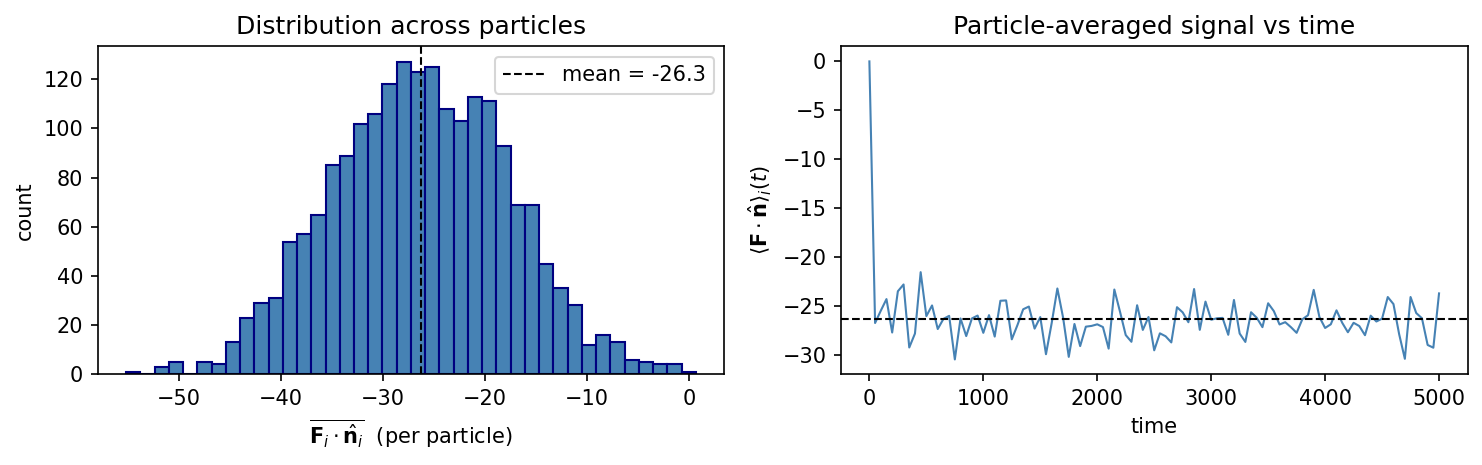

In [3]:
s_per_particle = s.mean(axis=0)                       # (N,)
s_global       = s_per_particle.mean()
s_sem          = s_per_particle.std(ddof=1) / np.sqrt(N)

print(f'<F . n>  per particle       : mean over particles = {s_global:.4g}')
print(f'                              SEM across particles = {s_sem:.2g}')
print(f'                              min / max            = {s_per_particle.min():.4g} / {s_per_particle.max():.4g}')

# Optional reference: the active drive itself is f0, so |<F.n>| / f0 is
# the fraction of self-propulsion that is being directly opposed by
# pair interactions in steady state.
if traj.f0 > 0:
    print(f'\nf0 = {traj.f0:.4g},  <F.n> / f0 = {s_global / traj.f0:+.3f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))

ax[0].hist(s_per_particle, bins=40, color='steelblue', edgecolor='navy')
ax[0].axvline(s_global, color='k', lw=1, ls='--', label=f'mean = {s_global:.3g}')
ax[0].set_xlabel(r'$\overline{\mathbf{F}_i \cdot \hat{\mathbf{n}}_i}$  (per particle)')
ax[0].set_ylabel('count')
ax[0].set_title('Distribution across particles')
ax[0].legend()

ax[1].plot(times, s.mean(axis=1), color='steelblue', lw=1)
ax[1].axhline(s_global, color='k', lw=1, ls='--')
ax[1].set_xlabel('time')
ax[1].set_ylabel(r'$\langle \mathbf{F}\cdot\hat{\mathbf{n}}\rangle_i(t)$')
ax[1].set_title('Particle-averaged signal vs time')

plt.tight_layout()
plt.show()

## 2. Cross-correlation $C(\tau)$

Time-lagged dot product, averaged over particles and time origins:

$$
C(\tau) = \big\langle \mathbf{F}_i(t+\tau) \cdot \hat{\mathbf{n}}_i(t) \big\rangle_{i,\, t}.
$$

At $\tau = 0$ this matches the time-averaged value computed above. For $\tau > 0$, it asks: "how does the orientation _now_ correlate with the interaction force the particle will feel _later_?" Negative lags swap the roles. The dot product decomposes into independent scalar cross-correlations of $F_x$ with $n_x$ and $F_y$ with $n_y$, computed below with `scipy.signal.correlate` (FFT-based) and normalised by the number of overlapping samples (unbiased estimator).

C(tau = 0)            = -26.2935
<F.n>  (from above)   = -26.2935
agreement (should be ~0): 4.26e-14


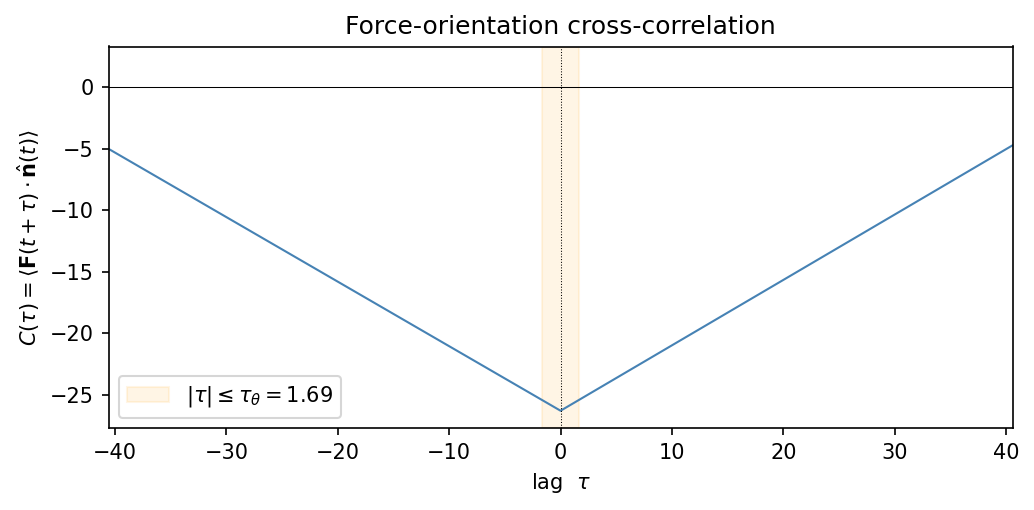

In [7]:
from scipy.signal import correlate, correlation_lags

# Per-particle cross-correlation of F_x with n_x and F_y with n_y, then sum
# them to get the dot-product cross-correlation. Average over particles.
lags = correlation_lags(T, T, mode='full')             # length 2T-1, integer lag in frames
norm = T - np.abs(lags)                                 # overlapping samples per lag (unbiased)

cc = np.zeros_like(lags, dtype=np.float64)
for k in range(2):                                      # x and y components
    for i in range(N):
        cc += correlate(forces[:, i, k], nhat[:, i, k], mode='full')
cc /= (N * norm)                                        # mean over particles and overlaps

# Convert frame lag to physical-time lag using output_dt.
dt_out = float(traj.params.get('output_dt', times[1] - times[0] if T > 1 else 1.0))
tau    = lags * dt_out

# Sanity check: C(0) must equal the time-averaged <F.n> from cell 1.
C0 = cc[lags == 0][0]
print(f'C(tau = 0)            = {C0:.6g}')
print(f'<F.n>  (from above)   = {s_global:.6g}')
print(f'agreement (should be ~0): {abs(C0 - s_global):.2e}')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(tau, cc, color='steelblue', lw=1)
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel(r'lag  $\tau$')
ax.set_ylabel(r'$C(\tau) = \langle \mathbf{F}(t+\tau) \cdot \hat{\mathbf{n}}(t) \rangle$')
ax.set_title('Force-orientation cross-correlation')

# Zoom in on the central region — beyond a few orientation-persistence times
# (tau_theta) the signal decorrelates and the unbiased estimator gets noisy.
tau_theta = traj.tau_theta if traj.tau_theta > 0 else (tau.max() / 4)
ax.set_xlim(-24 * tau_theta, 24 * tau_theta)
if traj.tau_theta > 0:
    ax.axvspan(-tau_theta, tau_theta, color='orange', alpha=0.1,
               label=fr'$|\tau| \leq \tau_\theta = {tau_theta:.3g}$')
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Force–orientation alignment vs local density

For each particle in each frame we estimate a local density from a Voronoi tessellation of the (periodically tiled) point cloud, then bin the per-particle dot product $\mathbf{F}_i \cdot \hat{\mathbf{n}}_i$ against it.

**Local density estimator.** A Voronoi diagram assigns every particle a polygonal cell containing all points closer to it than to any other particle. The local packing fraction is the particle's own area divided by its Voronoi cell area,

$$\phi_i \;=\; \frac{\pi (\sigma/2)^2}{A^{\mathrm{vor}}_i},$$

which is bounded above by the 2-D close-packed limit $\pi/(2\sqrt{3}) \approx 0.9069$ and shrinks as the cell grows in sparse regions. Periodic boundaries are handled by tiling the system into the eight surrounding image cells and tessellating the $9N$-point superset; the central $N$ particles all then have finite, well-defined cells that match the periodic geometry exactly. We read each cell's area with the shoelace formula.

If interactions oppose self-propulsion preferentially in dense regions (particles pushing into a crowd), $\langle \mathbf{F} \cdot \hat{\mathbf{n}} \rangle$ should grow more negative with $\phi_i$.

mean local phi   = 0.591
median local phi = 0.634
phi range (1-99%) = [0.017, 0.929]
2-D close-packed limit = pi / (2 sqrt(3)) = 0.9069
global phi (input parameter) = 0.500


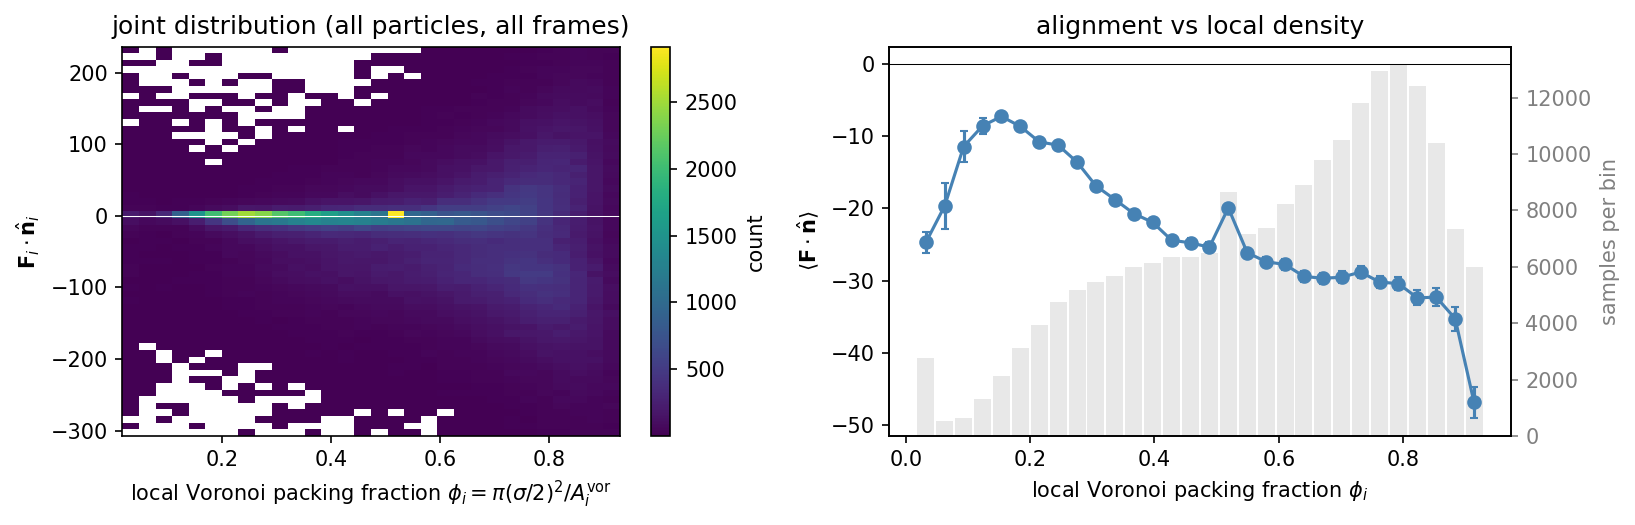

In [9]:
from scipy.spatial import Voronoi


def local_voronoi_packing_fraction(positions: np.ndarray, sigma: float,
                                   Lx: float, Ly: float) -> np.ndarray:
    """
    Per-particle local packing fraction phi_i = pi (sigma/2)^2 / A_i,
    where A_i is the area of particle i's Voronoi cell under PBC.

    The system is tiled into the 8 image cells before tessellation so that
    the N central particles all have finite cells consistent with periodic
    geometry. Cell areas are computed via the shoelace formula.
    """
    N = positions.shape[0]
    shifts = np.array(
        [(dx * Lx, dy * Ly) for dx in (-1, 0, 1) for dy in (-1, 0, 1)]
    )                                                                # (9, 2)
    images = (positions[None, :, :] + shifts[:, None, :]).reshape(-1, 2)  # (9N, 2)

    vor = Voronoi(images)
    particle_area = np.pi * (sigma / 2.0) ** 2

    phi = np.empty(N)
    for i in range(N):
        region = vor.regions[vor.point_region[i]]
        # Central particles in a tiled box should always have closed cells; if
        # something pathological happens (collinear points, etc.) skip to NaN.
        if not region or -1 in region or len(region) < 3:
            phi[i] = np.nan
            continue
        v    = vor.vertices[region]
        x, y = v[:, 0], v[:, 1]
        area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
        phi[i] = particle_area / area
    return phi


# Per-particle, per-frame local packing fraction.
phi_per = np.empty((T, N))
for k in range(T):
    pos        = traj.positions(k)
    Lx_k, Ly_k = traj.frame_box(k)
    phi_per[k] = local_voronoi_packing_fraction(pos, traj.sigma, Lx_k, Ly_k)

phi_flat = phi_per.ravel()
s_flat   = s.ravel()                                               # F . n from cell 3

# Drop any NaNs from degenerate cells before binning.
ok       = np.isfinite(phi_flat) & np.isfinite(s_flat)
phi_flat = phi_flat[ok]
s_flat   = s_flat[ok]

phi_global = traj.params.get('phi', None)
print(f'mean local phi   = {phi_flat.mean():.3f}')
print(f'median local phi = {np.median(phi_flat):.3f}')
print(f'phi range (1-99%) = [{np.percentile(phi_flat, 1):.3f}, {np.percentile(phi_flat, 99):.3f}]')
print(f'2-D close-packed limit = pi / (2 sqrt(3)) = {np.pi / (2 * np.sqrt(3)):.4f}')
if phi_global is not None:
    print(f'global phi (input parameter) = {phi_global:.3f}')

# --- Bin <F . n> against local density --------------------------------------
nbins          = 30
phi_lo, phi_hi = np.percentile(phi_flat, [1, 99])                  # ignore extreme tails
edges          = np.linspace(phi_lo, phi_hi, nbins + 1)
centers        = 0.5 * (edges[:-1] + edges[1:])

bin_idx = np.clip(np.searchsorted(edges, phi_flat, side='right') - 1, 0, nbins - 1)
mean_b  = np.full(nbins, np.nan)
sem_b   = np.full(nbins, np.nan)
count_b = np.zeros(nbins, dtype=np.int64)
for b in range(nbins):
    sel = s_flat[bin_idx == b]
    count_b[b] = sel.size
    if sel.size > 1:
        mean_b[b] = sel.mean()
        sem_b[b]  = sel.std(ddof=1) / np.sqrt(sel.size)

# --- Plot --------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Joint distribution: 2D histogram of (phi_i, F.n) across all particles & frames.
s_lo, s_hi = np.percentile(s_flat, [0.5, 99.5])
h = axes[0].hist2d(
    phi_flat, s_flat,
    bins=[edges, np.linspace(s_lo, s_hi, 60)],
    cmap='viridis', cmin=1,
)
axes[0].axhline(0, color='w', lw=0.5)
axes[0].set_xlabel(r'local Voronoi packing fraction $\phi_i = \pi(\sigma/2)^2 / A^{\mathrm{vor}}_i$')
axes[0].set_ylabel(r'$\mathbf{F}_i \cdot \hat{\mathbf{n}}_i$')
axes[0].set_title('joint distribution (all particles, all frames)')
plt.colorbar(h[3], ax=axes[0], label='count')

# Binned mean with SEM error bars; secondary axis shows the bin populations.
axes[1].errorbar(centers, mean_b, yerr=sem_b, fmt='o-', color='steelblue',
                 capsize=2, label=r'$\langle \mathbf{F}\cdot\hat{\mathbf{n}} \rangle$ per bin')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel(r'local Voronoi packing fraction $\phi_i$')
axes[1].set_ylabel(r'$\langle \mathbf{F} \cdot \hat{\mathbf{n}} \rangle$')
axes[1].set_title('alignment vs local density')

ax_count = axes[1].twinx()
ax_count.bar(centers, count_b, width=(edges[1] - edges[0]) * 0.9,
             color='lightgray', alpha=0.5, zorder=0)
ax_count.set_ylabel('samples per bin', color='gray')
ax_count.tick_params(axis='y', colors='gray')
ax_count.set_zorder(0)
axes[1].set_zorder(1)
axes[1].patch.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
traj.close()